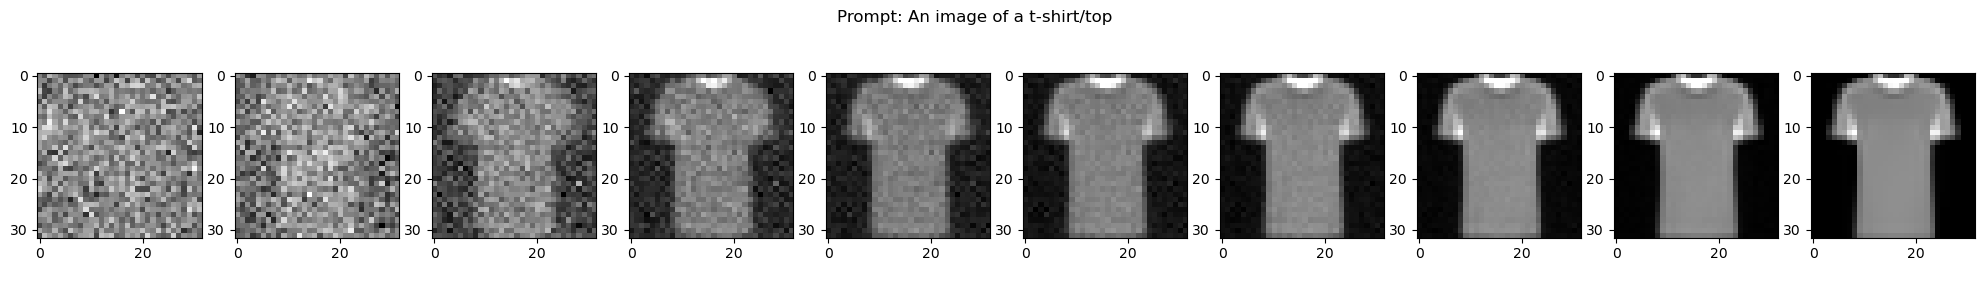

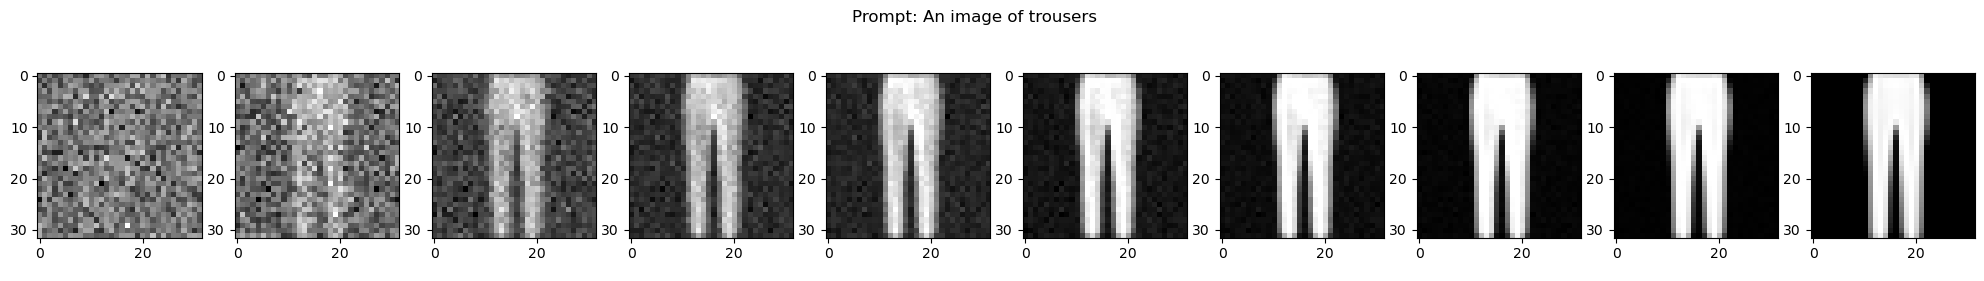

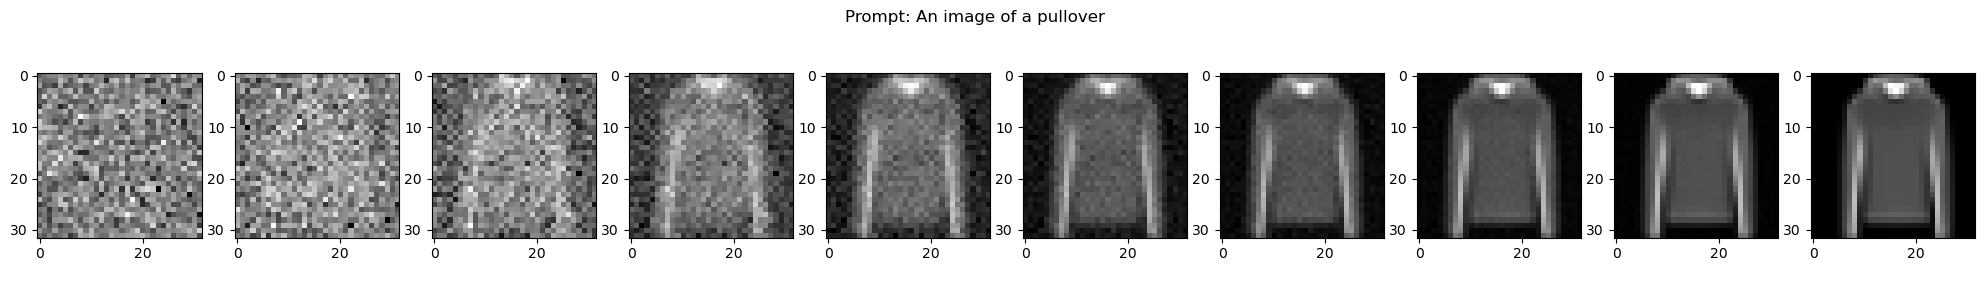

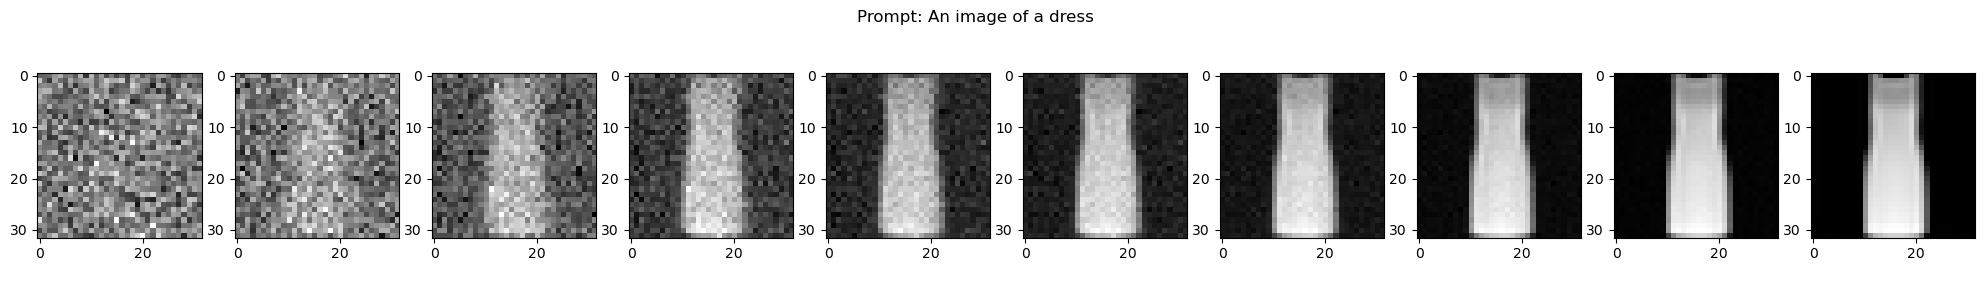

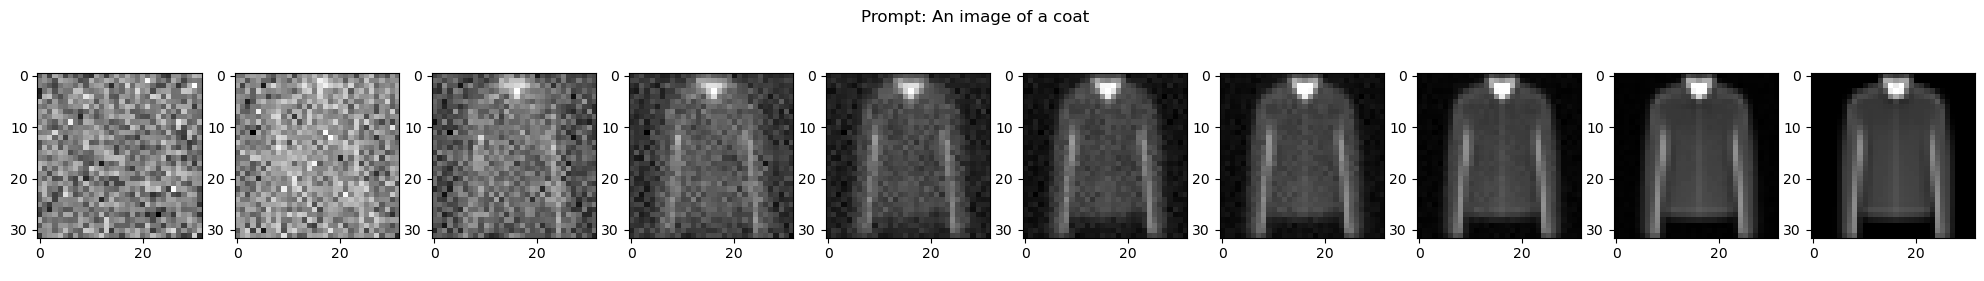

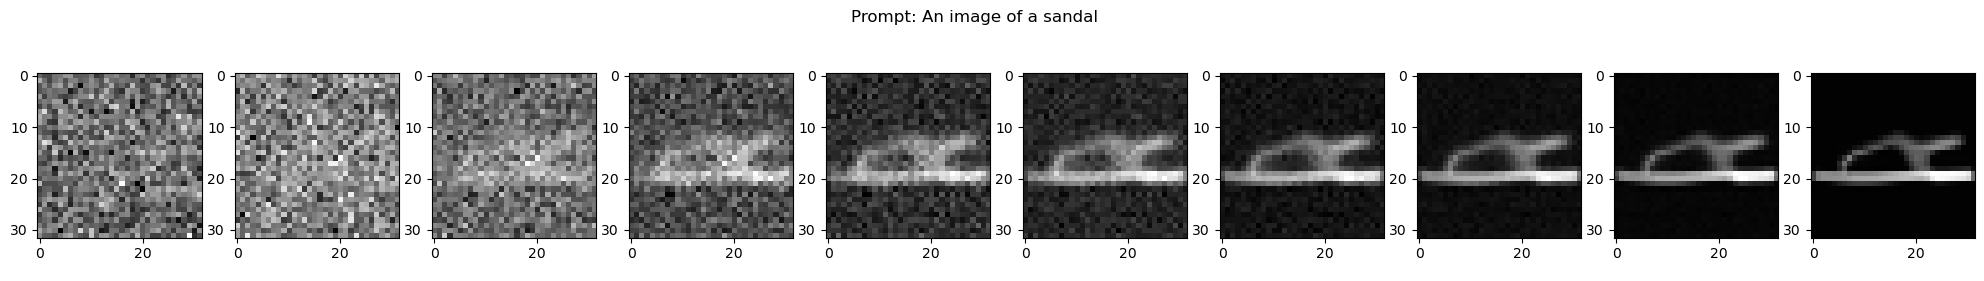

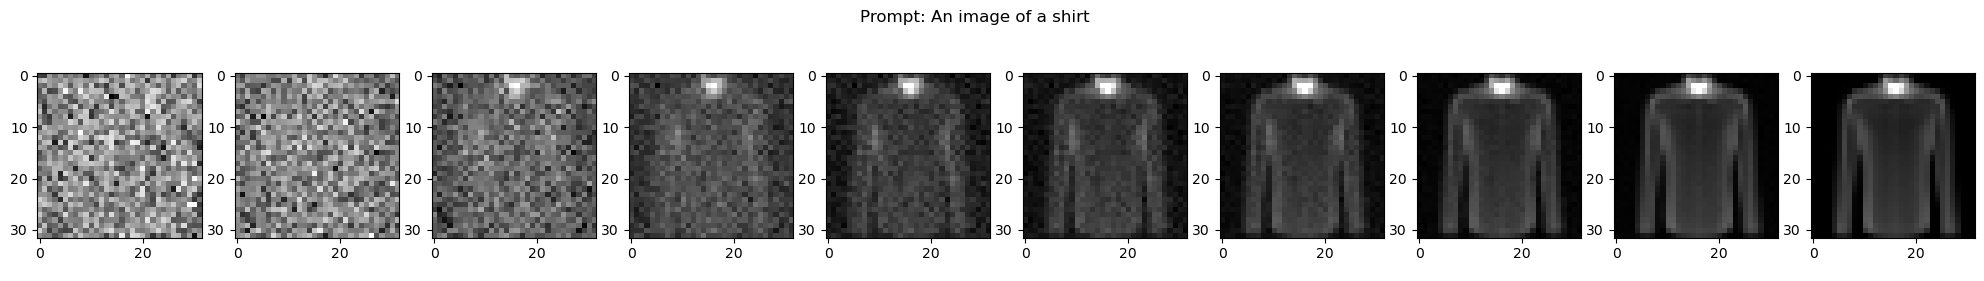

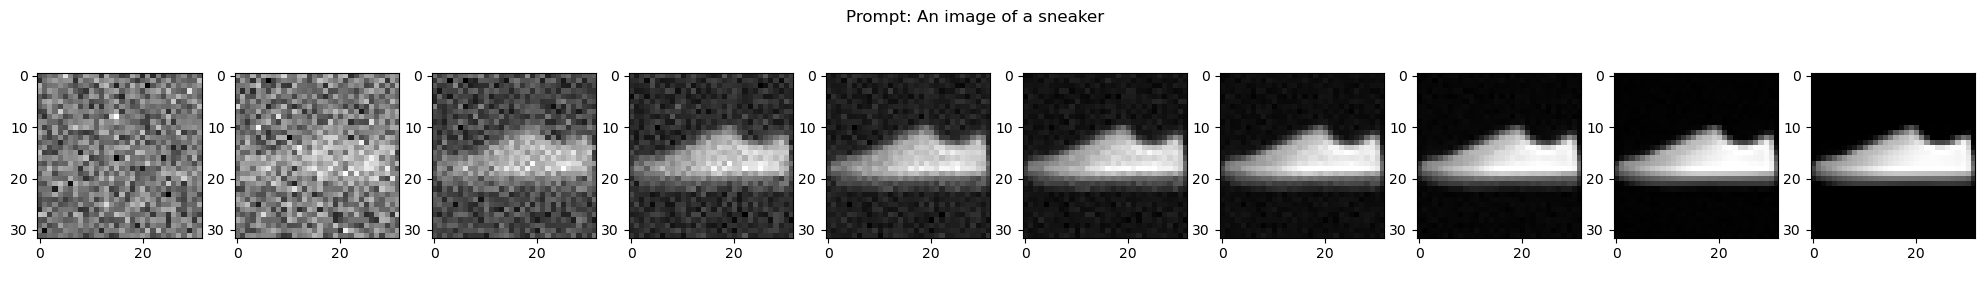

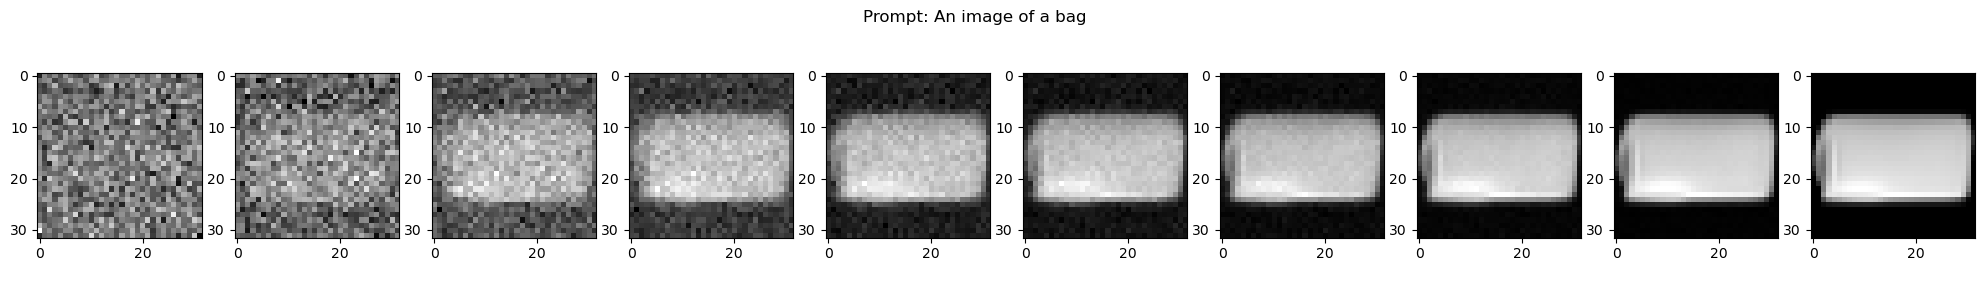

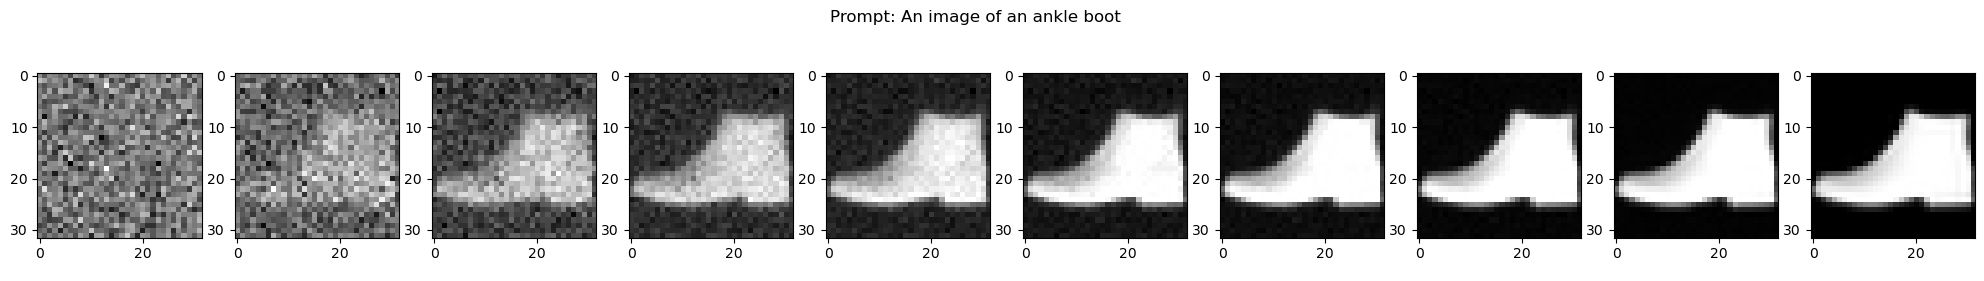

In [1]:
from model.decoder import sample_plot_image
from data.FMNISTConfig import FMNISTConfig
from data.data_utils import tokenizer
import torch

config = FMNISTConfig()
config.clip.model_location = "trained_models/clip_fmnist.pt"
config.prior.model_location = "trained_models/prior_fmnist.pt"
config.decoder.model_location = "trained_models/decoder_fmnist.pt"

captions = {
    0: "An image of a t-shirt/top",
    1: "An image of trousers",
    2: "An image of a pullover",
    3: "An image of a dress",
    4: "An image of a coat",
    5: "An image of a sandal",
    6: "An image of a shirt",
    7: "An image of a sneaker",
    8: "An image of a bag",
    9: "An image of an ankle boot"
}

sample_captions = torch.stack([tokenizer(x, text_seq_length=config.text_seq_length)[
                              0] for x in captions.values()]).to(config.device)
sample_masks = torch.stack([tokenizer(x, text_seq_length=config.text_seq_length)[
                           1] for x in captions.values()]).to(config.device)

for i in range(len(sample_captions)):
    caption = sample_captions[None, (i % len(sample_captions))]
    mask = sample_masks[None, (i % len(sample_masks))]
    test = sample_plot_image(config, caption, mask)
